# Integration (1 degree mosaicity)

Every detector frame is integrated azimuthally over a q-window around each of
the selected powder rings, giving the array `I[translation, omega, eta, ring]` that the
texture tomography is fitted to. The array is written as a raw memmap (`.bin`)
next to a `.json` with all parameters (see `integration/integrated_data.py`).

The dataset-specific reading lives in `integration/frame_loader.py`. This
notebook only uses its generic interface.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import json
import os
import time
from concurrent.futures import ProcessPoolExecutor, wait, FIRST_COMPLETED
from datetime import datetime, timezone
from multiprocessing import shared_memory

import numpy as np
import matplotlib.pyplot as plt
import pyFAI
from matplotlib.patches import Rectangle
from scipy.ndimage import maximum_filter
from diffractom import Material
from integration.frame_loader import (SimulatedDataset, PONI_PATH, PARAMETERS_AL, POLARIZATION_FACTOR, output_path,
                                      read_batch_into_shm, dark)
from integration.integrated_data import IntegratedData
from simtools import paths

dark()

In [2]:
SAMPLE = "domains_mosaicity_1p0deg"
INTEGRATED_PATH = paths.integrated_path(SAMPLE)  # earlier run, without polarization correction
OUTPUT_PATH = output_path(SAMPLE)                # polarization-corrected run, written by this notebook

## A few frames
Frames are max-filtered for display only, so that peaks of a few pixels stay visible.

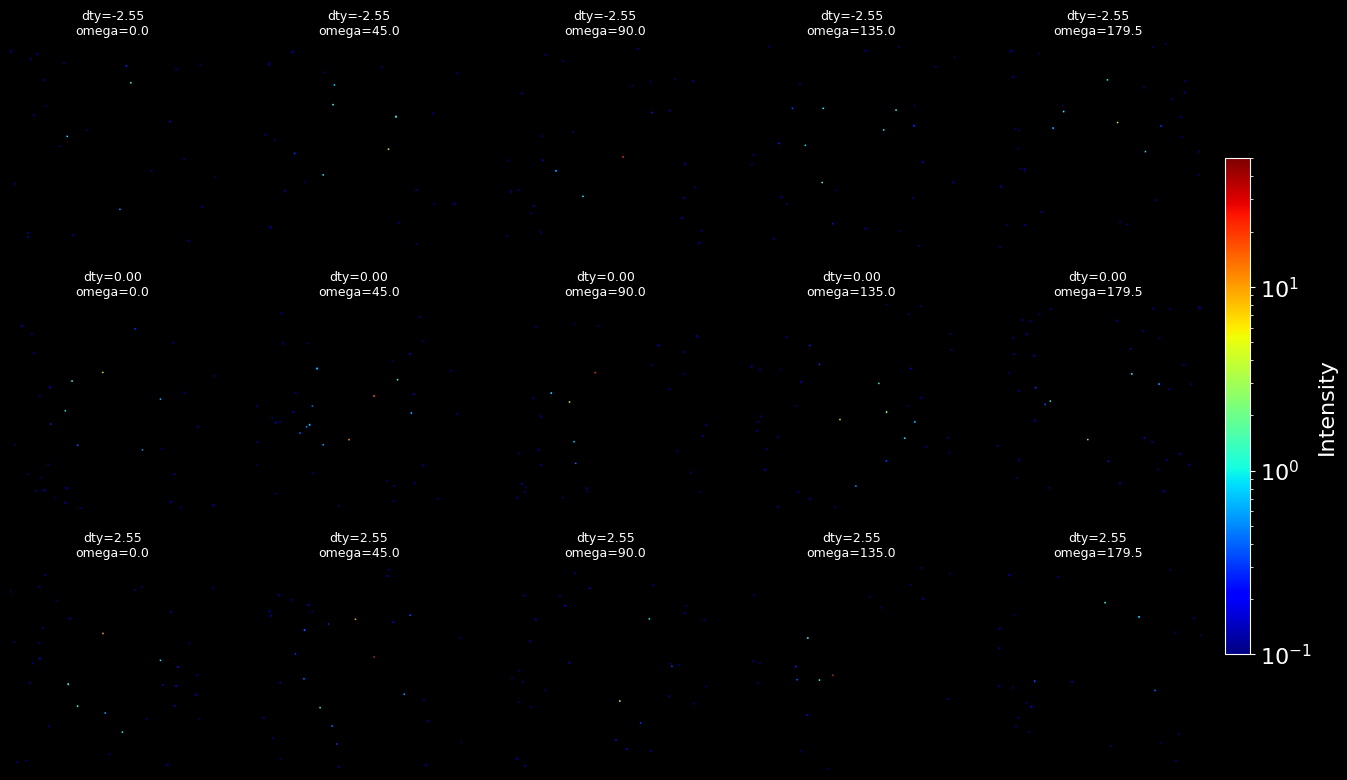

In [3]:
target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 45, 90, 135, 179.5]

with SimulatedDataset(SAMPLE) as ds:
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]
    fig, axes = plt.subplots(len(i_trans_list), len(target_omega_deg),
                             figsize=(3.2 * len(target_omega_deg), 3.2 * len(i_trans_list)), squeeze=False)
    for row, i_trans in enumerate(i_trans_list):
        omega = ds.omega(i_trans)
        dty_val = ds.translations()[i_trans]
        for col, target in enumerate(target_omega_deg):
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)
            ax = axes[row, col]
            im = ax.imshow(maximum_filter(frame, size=15), vmin=0.1, vmax=50, norm="log", cmap="jet")
            ax.set_title(f"dty={dty_val:.2f}\nomega={omega[i_omega]:.1f}", fontsize=9)
            ax.axis("off")
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Intensity")
    plt.show()

## Choose the rings
The frames above are integrated with a fine radial binning, and the result is compared with the powder peaks predicted from the unit cell in `Al.par`.

In [4]:
ai = pyFAI.load(PONI_PATH)
npt_rad = 2000
npt_azim = 180

def read_par_file(path):
    params = {}
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    return params

I_sum, q, chi = None, None, None
with SimulatedDataset(SAMPLE) as ds:
    mask = ds.mask()
    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            res = ai.integrate2d(ds.frame(i_trans, i_omega), npt_rad=npt_rad, npt_azim=npt_azim,
                                 unit="q_nm^-1", mask=mask, method=("no", "csr", "opencl"),
                                 polarization_factor=POLARIZATION_FACTOR)
            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal
            I_sum += res.intensity
I_sum = np.nan_to_num(I_sum)

par = read_par_file(PARAMETERS_AL)
mat = Material.from_lattice_parameters(
    a=float(par["cell__a"]), b=float(par["cell__b"]), c=float(par["cell__c"]),
    alpha=float(par["cell_alpha"]), beta=float(par["cell_beta"]), gamma=float(par["cell_gamma"]),
    space_group_number=int(par["cell_lattice_[P,A,B,C,I,F,R]"]),
    wavelength_A=float(par["wavelength"]),
    q_min=q.min() / 10, q_max=q.max() / 10,  # nm^-1 -> A^-1
)
q_peaks_nm = np.unique(np.round(2 * np.pi / mat.reflections["d_spacing"] * 10, 8))
print(f"{len(q_peaks_nm)} distinct predicted peaks within the detector's q-range")

/zhome/71/c/146676/miniconda3/envs/textom/lib/python3.11/site-packages/pyopencl/__init__.py:570: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),


43 distinct predicted peaks within the detector's q-range


The 8 lowest-q rings (111, 200, 220, 311, 222, 400, 331, 420) are used,
each summed over a window of full width `Q_WIDTH_NM` = 2 nm^-1 (±0.1 1/A).
These are the rings and window used in the article.

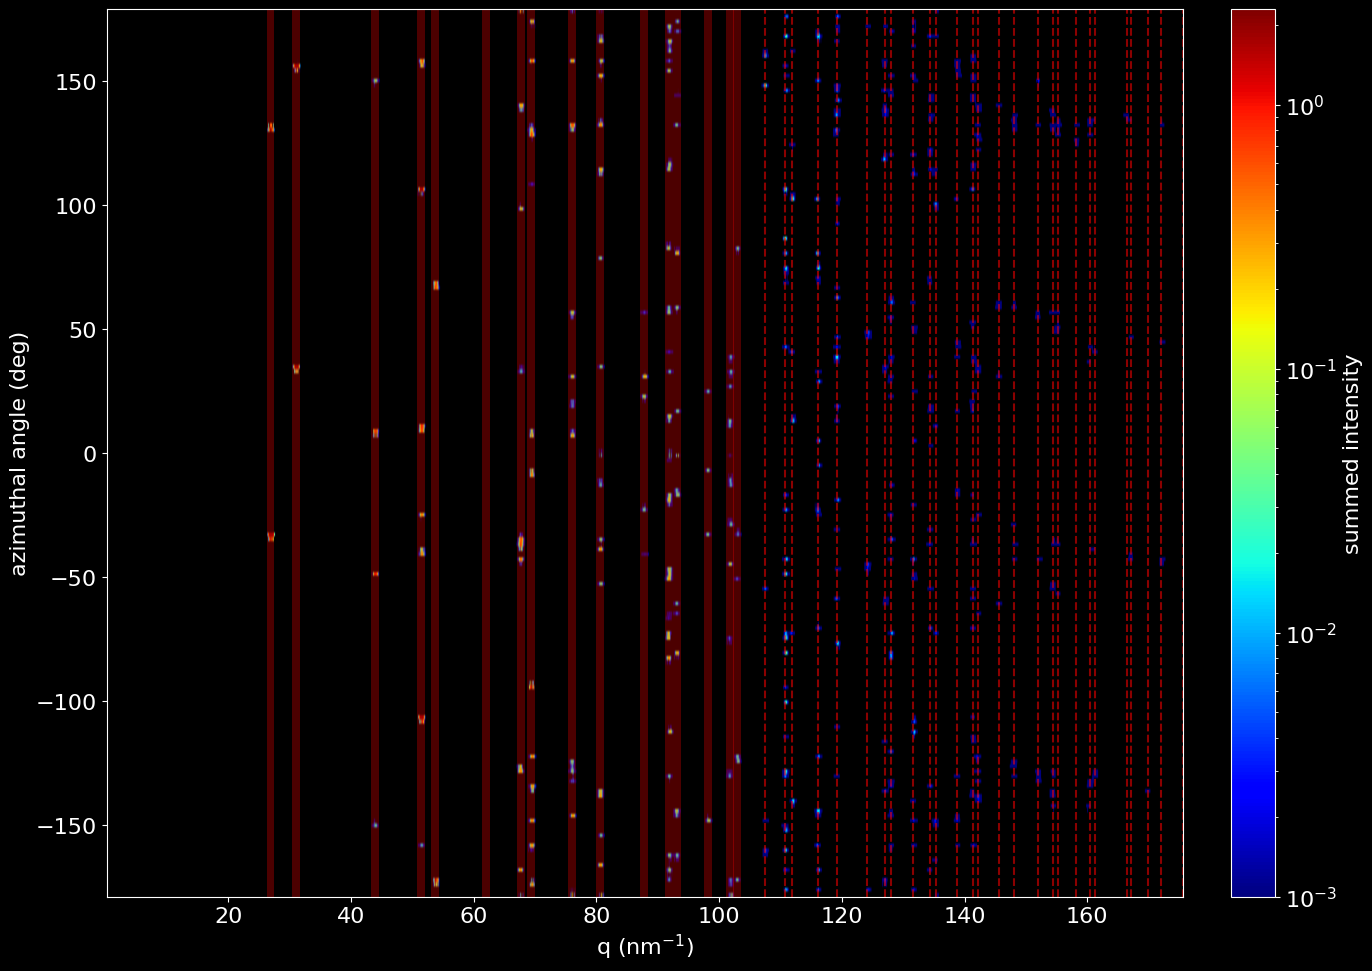

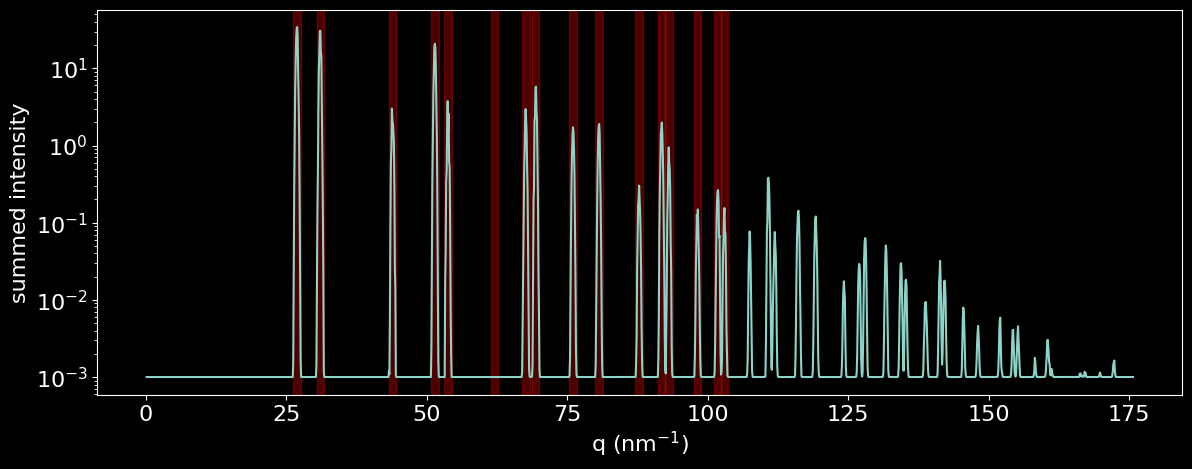

In [9]:
Q_WIDTH_NM = 1.3  # full width of the window around each ring, nm^-1
N_RINGS = 16

selected_peaks = q_peaks_nm[:N_RINGS]
excluded_peaks = q_peaks_nm[N_RINGS:]

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
vmin = max(I_sum[I_sum > 0].min(), 1e-3)
im = ax.imshow(I_sum, extent=[q.min(), q.max(), chi.min(), chi.max()], origin="lower", aspect="auto",
               vmin=vmin, vmax=np.percentile(I_sum, 99.99), norm="log", cmap="jet")
for peak in selected_peaks:
    ax.add_patch(Rectangle((peak - Q_WIDTH_NM / 2, chi.min()), Q_WIDTH_NM, chi.max() - chi.min(),
                           facecolor="red", alpha=0.3, edgecolor=None))
for peak in excluded_peaks:
    ax.vlines(peak, chi.min(), chi.max(), color="red", linewidth=1.5, linestyle="--", alpha=0.55)
ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity")
plt.tight_layout()
plt.show()

profile = I_sum.sum(axis=0)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.semilogy(q, profile + 1e-3)
for peak in selected_peaks:
    ax.axvspan(peak - Q_WIDTH_NM / 2, peak + Q_WIDTH_NM / 2, color="red", alpha=0.3)
ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("summed intensity")
plt.show()

## Parameters

The binning reproduces the integration used in the article:

* radial: `NPT_RAD` = 2000 bins over the full q-range of the detector. A ring's value is the sum
  of the (mean-per-bin) pyFAI intensities of the bins inside its window, so it scales with the bin
  width. The regularisation parameters of the texture tomography are tied to this scale.
* azimuthal: `N_ETA` = 180 bins over pyFAI's default azimuthal range. For this detector
  that range is set by the pixel positions, not exactly (-180, 180) deg, so the actual bin centres
  are read from pyFAI and written to the json.
* polarization: corrected with `polarization_factor = POLARIZATION_FACTOR` (+1, horizontal), the
  polarization the simulation applied (`frame_loader.py`). Solid angle: pyFAI default. Lorentz: not
  corrected, the texture tomography model accounts for it.

Everything is written to the json before the integration starts.

In [10]:
import inspect

NPT_RAD = 2000
N_ETA = 180
INTEGRATION_METHOD = ("no", "csr", "opencl")
INTEGRATION_UNIT = "q_nm^-1"

with SimulatedDataset(SAMPLE) as ds:
    probe = ai.integrate2d(ds.frame(0, 0), npt_rad=NPT_RAD, npt_azim=N_ETA, unit=INTEGRATION_UNIT,
                           mask=ds.mask(), method=INTEGRATION_METHOD, polarization_factor=POLARIZATION_FACTOR)
eta_centres = probe.azimuthal
eta_step = eta_centres[1] - eta_centres[0]
ETA_RANGE_DEG = (float(eta_centres[0] - eta_step / 2), float(eta_centres[-1] + eta_step / 2))
print(f"eta bins: {N_ETA} x {eta_step:.4f} deg over {ETA_RANGE_DEG[0]:.3f} .. {ETA_RANGE_DEG[1]:.3f} deg")

# correction settings as the installed pyFAI actually applies them (read, not assumed)
integrate2d_args = inspect.signature(ai.integrate2d).parameters
assert "polarization_factor" in integrate2d_args, "this pyFAI's integrate2d has no polarization_factor argument"
solid_angle_applied = bool(integrate2d_args["correctSolidAngle"].default)  # not passed below, so the default applies
if "polarization_axis_offset" in integrate2d_args:
    pol_axis_offset_arg = integrate2d_args["polarization_axis_offset"].default
    pol_axis_offset_effective = pol_axis_offset_arg
else:
    pol_axis_offset_arg = None   # integrate2d has no such argument ...
    pol_axis_offset_effective = inspect.signature(ai.polarization).parameters["axis_offset"].default  # ... Geometry.polarization default is used

json_path = OUTPUT_PATH + ".json"
bin_path = OUTPUT_PATH + ".bin"

# never overwrite a finished run; an interrupted one (integration_complete=False) may be redone
if os.path.exists(json_path):
    with open(json_path) as f:
        if json.load(f).get("integration_complete", False):
            raise FileExistsError(
                f"{json_path} is a completed integration -- refusing to overwrite it. "
                "Change OUTPUT_SUFFIX in frame_loader.py, or delete the old pair deliberately."
            )

with SimulatedDataset(SAMPLE) as ds:
    translations = ds.translations()
    n_trans = ds.n_translations
    omega = ds.omega(0)  # rotation sequence, identical for every translation
    n_omega = len(omega)
    for i_trans in range(n_trans):
        assert np.allclose(ds.omega(i_trans), omega)

def reflections_for_q(mat, q_values_nm, tol=1e-6):
    """Match each |q| ring back to every (h,k,l) family that lands on it."""
    q_all_nm = 2 * np.pi / mat.reflections["d_spacing"] * 10
    out = []
    for qv in q_values_nm:
        matches = np.where(np.abs(q_all_nm - qv) < tol)[0]
        out.append({
            "q_nm": float(qv),
            "hkl": [mat.reflections["hkl"][i].tolist() for i in matches],
            "multiplicity": [int(mat.reflections["multiplicity"][i]) for i in matches],
            "d_spacing_A": float(mat.reflections["d_spacing"][matches[0]]),
            "two_theta_rad": float(mat.reflections["two_theta"][matches[0]]),
        })
    return out

params = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "integration_complete": False,
    "geometry": {
        "poni_path": PONI_PATH,
        "parameters_path": PARAMETERS_AL,
        "mask_path": None,
        "wavelength_A": ai.wavelength * 1e10,
    },
    "material": {
        "space_group_number": mat.space_group_number,
        "space_group_symbol": mat.space_group_symbol,
        "lattice_params": mat.lattice_params,
    },
    "rings": {
        "q_width_nm": Q_WIDTH_NM,
        "npt_rad": NPT_RAD,
        "n_eta": N_ETA,
        "eta_range_deg": list(ETA_RANGE_DEG),
        "eta_deg": eta_centres.tolist(),
        "selected": reflections_for_q(mat, selected_peaks),
    },
    "integration": {
        "npt_rad": NPT_RAD,
        "method": list(INTEGRATION_METHOD),
        "unit": INTEGRATION_UNIT,
        "azimuth_range_deg": None,  # not passed: pyFAI default, actual bins in rings.eta_range_deg / eta_deg
        "radial_range_nm": None,    # not passed: full q-range of the detector
    },
    "corrections": {
        "polarization": {
            "applied": POLARIZATION_FACTOR is not None,
            "method": "pyFAI integrate2d polarization_factor",
            "factor": POLARIZATION_FACTOR,
            "axis_offset": pol_axis_offset_arg,
            "axis_offset_effective_rad": pol_axis_offset_effective,
            "convention": "pyFAI: +1 horizontal, -1 vertical, 0 circular",
            "pyfai_version": pyFAI.version,
        },
        "solid_angle": {"applied": solid_angle_applied, "note": "pyFAI default (correctSolidAngle), unchanged"},
        "lorentz": {"applied": False, "note": "intentionally not corrected; handled by the downstream fitting model"},
    },
    "scan": {
        "n_translations": n_trans,
        "n_omega": n_omega,
        "translations_dty": translations.tolist(),
        "omega_deg": omega.tolist(),
    },
    "output": {
        "bin_path": bin_path,
        "dtype": "float32",
        "shape": [n_trans, n_omega, N_ETA, len(selected_peaks)],
        "shape_axes": ["translation", "omega", "eta", "q_ring"],
        "memmap_order": "C",
    },
}
with open(json_path, "w") as f:
    json.dump(params, f, indent=2)
print(f"Output array shape: {params['output']['shape']}, {4 * np.prod(params['output']['shape']) / 1e9:.2f} GB")
print(f"Corrections: {json.dumps(params['corrections'], indent=1)}")
print(f"Integration: {json.dumps(params['integration'])}")
print(f"Wrote parameters to {json_path}")

eta bins: 180 x 1.9997 deg over -179.972 .. 179.972 deg
Output array shape: [103, 360, 180, 16], 0.43 GB
Wrote parameters to /dtu-compute/msaca/adaptive_basis_simulations/processed/domains_mosaicity_1p0deg/domains_mosaicity_1p0deg_integrated.json


## Integrate
Worker processes read and densify batches of frames into shared memory, and the main process integrates them on the GPU. One `integrate2d` call per frame covers all rings; the ring windows are then summed out with a 0/1 matrix.

In [11]:
with open(json_path) as f:
    params = json.load(f)

ai = pyFAI.load(params["geometry"]["poni_path"])
# every integration setting comes from the json, so what is recorded is exactly what runs
Q_WIDTH_NM = params["rings"]["q_width_nm"]
N_eta = params["rings"]["n_eta"]
integ = params["integration"]
npt_rad = integ["npt_rad"]
method = tuple(integ["method"])
unit = integ["unit"]
pol_factor = params["corrections"]["polarization"]["factor"]
assert integ["azimuth_range_deg"] is None and integ["radial_range_nm"] is None  # pyFAI defaults, as recorded
print(f"integrating with polarization_factor={pol_factor}, npt_rad={npt_rad}, method={method}")
selected_q = np.array([r["q_nm"] for r in params["rings"]["selected"]])

radial_ranges = [(q0 - Q_WIDTH_NM / 2, q0 + Q_WIDTH_NM / 2) for q0 in selected_q]
N_rings = len(radial_ranges)

shape = tuple(params["output"]["shape"])
I_out = np.memmap(params["output"]["bin_path"], dtype=params["output"]["dtype"], mode="w+", shape=shape)

read_batch_size = 10
n_worker_processes = min(16, len(os.sched_getaffinity(0)))
n_shm_buffers = n_worker_processes + 2

with SimulatedDataset(SAMPLE) as ds:
    mask = ds.mask()
    frame_shape = ds.frame_shape
    dtype_str = ds.frame_dtype
    buf_nbytes = read_batch_size * np.prod(frame_shape) * np.dtype(dtype_str).itemsize
    print(f"shared-memory pool: {n_shm_buffers} buffers x {buf_nbytes/1e6:.0f} MB = {n_shm_buffers * buf_nbytes / 1e9:.2f} GB")

    res0 = ai.integrate2d(ds.frame(0, 0), npt_rad=npt_rad, npt_azim=N_eta, unit=unit, mask=mask,
                          method=method, polarization_factor=pol_factor)
    assert np.allclose(res0.azimuthal, params["rings"]["eta_deg"], atol=1e-3), (
        "pyFAI's azimuthal bin centres don't match eta_deg in the json")
    ring_matrix = np.zeros((npt_rad, N_rings), dtype=np.float32)
    for i_ring, (lo, hi) in enumerate(radial_ranges):
        ring_matrix[(res0.radial >= lo) & (res0.radial < hi), i_ring] = 1.0

    shm_blocks = [shared_memory.SharedMemory(create=True, size=int(buf_nbytes)) for _ in range(n_shm_buffers)]
    shm_arrays = {shm.name: np.ndarray((read_batch_size,) + frame_shape, dtype=dtype_str, buffer=shm.buf)
                  for shm in shm_blocks}

    def integrate_translation(pool, path, abs_start, abs_stop, out_view, free_names):
        starts = list(range(abs_start, abs_stop, read_batch_size))
        pending = {}
        next_idx = 0

        def submit_next():
            nonlocal next_idx
            if next_idx >= len(starts) or not free_names:
                return
            name = free_names.pop()
            s = starts[next_idx]
            stop = min(s + read_batch_size, abs_stop)
            fut = pool.submit(read_batch_into_shm, path, s, stop, name, read_batch_size, frame_shape, dtype_str)
            pending[fut] = (s, stop, name)
            next_idx += 1

        while free_names and next_idx < len(starts):
            submit_next()

        while pending:
            done, _ = wait(pending.keys(), return_when=FIRST_COMPLETED)
            for fut in done:
                s, stop, name = pending.pop(fut)
                n = fut.result()
                buf = shm_arrays[name]
                batch_out = np.empty((n, N_eta, N_rings), dtype=np.float32)
                for i in range(n):
                    res = ai.integrate2d(buf[i], npt_rad=npt_rad, npt_azim=N_eta, unit=unit, mask=mask,
                                         method=method, polarization_factor=pol_factor)
                    batch_out[i] = res.intensity @ ring_matrix
                out_view[s - abs_start:s - abs_start + n] = batch_out
                free_names.append(name)
                submit_next()

    try:
        with ProcessPoolExecutor(max_workers=n_worker_processes) as pool:
            free_names = [shm.name for shm in shm_blocks]
            t0 = time.perf_counter()
            n_frames_done = 0
            for i_trans in range(ds.n_translations):
                assert ds.n_omega(i_trans) == shape[1]
                path, abs_start, abs_stop = ds.raw_location(i_trans)
                integrate_translation(pool, path, abs_start, abs_stop, I_out[i_trans], free_names)
                n_frames_done += ds.n_omega(i_trans)
                rate = n_frames_done / (time.perf_counter() - t0)
                if (i_trans + 1) % 10 == 0 or i_trans + 1 == ds.n_translations:
                    print(f"translation {i_trans + 1}/{ds.n_translations}  ({rate:.1f} fr/s, "
                          f"~{(shape[0] * shape[1] - n_frames_done) / rate / 60:.1f} min remaining)")
    finally:
        for shm in shm_blocks:
            shm.close()
            shm.unlink()

I_out.flush()
del I_out

params["integration_complete"] = True
with open(json_path, "w") as f:
    json.dump(params, f, indent=2)
print("Integration complete.")

shared-memory pool: 18 buffers x 168 MB = 3.02 GB
translation 10/103  (82.5 fr/s, ~6.8 min remaining)
translation 20/103  (85.5 fr/s, ~5.8 min remaining)
translation 30/103  (86.4 fr/s, ~5.1 min remaining)
translation 40/103  (87.3 fr/s, ~4.3 min remaining)
translation 50/103  (87.7 fr/s, ~3.6 min remaining)
translation 60/103  (87.8 fr/s, ~2.9 min remaining)
translation 70/103  (87.9 fr/s, ~2.3 min remaining)
translation 80/103  (87.8 fr/s, ~1.6 min remaining)
translation 90/103  (88.4 fr/s, ~0.9 min remaining)
translation 100/103  (88.8 fr/s, ~0.2 min remaining)
translation 103/103  (89.0 fr/s, ~0.0 min remaining)
Integration complete.


## Check the result
The integrated data can be loaded with `IntegratedData`. Shown below: a sinogram (intensity summed over eta) per ring.

IntegratedData: /dtu-compute/msaca/adaptive_basis_simulations/processed/domains_mosaicity_1p0deg/domains_mosaicity_1p0deg_integrated.json
  array   : (103, 360, 180, 16)  axes=['translation', 'omega', 'eta', 'q_ring']  float32  (0.43 GB, memmap)
  dty     : 103 steps, -5.201 .. 5.201
  omega   : 360 steps, 0 .. 179.5 deg
  eta     : 180 bins, range -179.972..179.972 deg
  rings   : 16, q_width = 1.3 nm^-1
    [ 0] q =   26.876 nm^-1   hkl: (-1, -1, -1)
    [ 1] q =   31.033 nm^-1   hkl: (-2, 0, 0)
    [ 2] q =   43.888 nm^-1   hkl: (-2, -2, 0)
    [ 3] q =   51.463 nm^-1   hkl: (-3, -1, -1)
    [ 4] q =   53.751 nm^-1   hkl: (-2, -2, -2)
    [ 5] q =   62.067 nm^-1   hkl: (-4, 0, 0)
    [ 6] q =   67.636 nm^-1   hkl: (-3, -3, -1)
    [ 7] q =   69.393 nm^-1   hkl: (-4, -2, 0)
    [ 8] q =   76.016 nm^-1   hkl: (-4, -2, -2)
    [ 9] q =   80.627 nm^-1   hkl: (-3, -3, -3), (-5, -1, -1)
    [10] q =   87.776 nm^-1   hkl: (-4, -4, 0)
    [11] q =   91.798 nm^-1   hkl: (-5, -3, -1)
    [12]

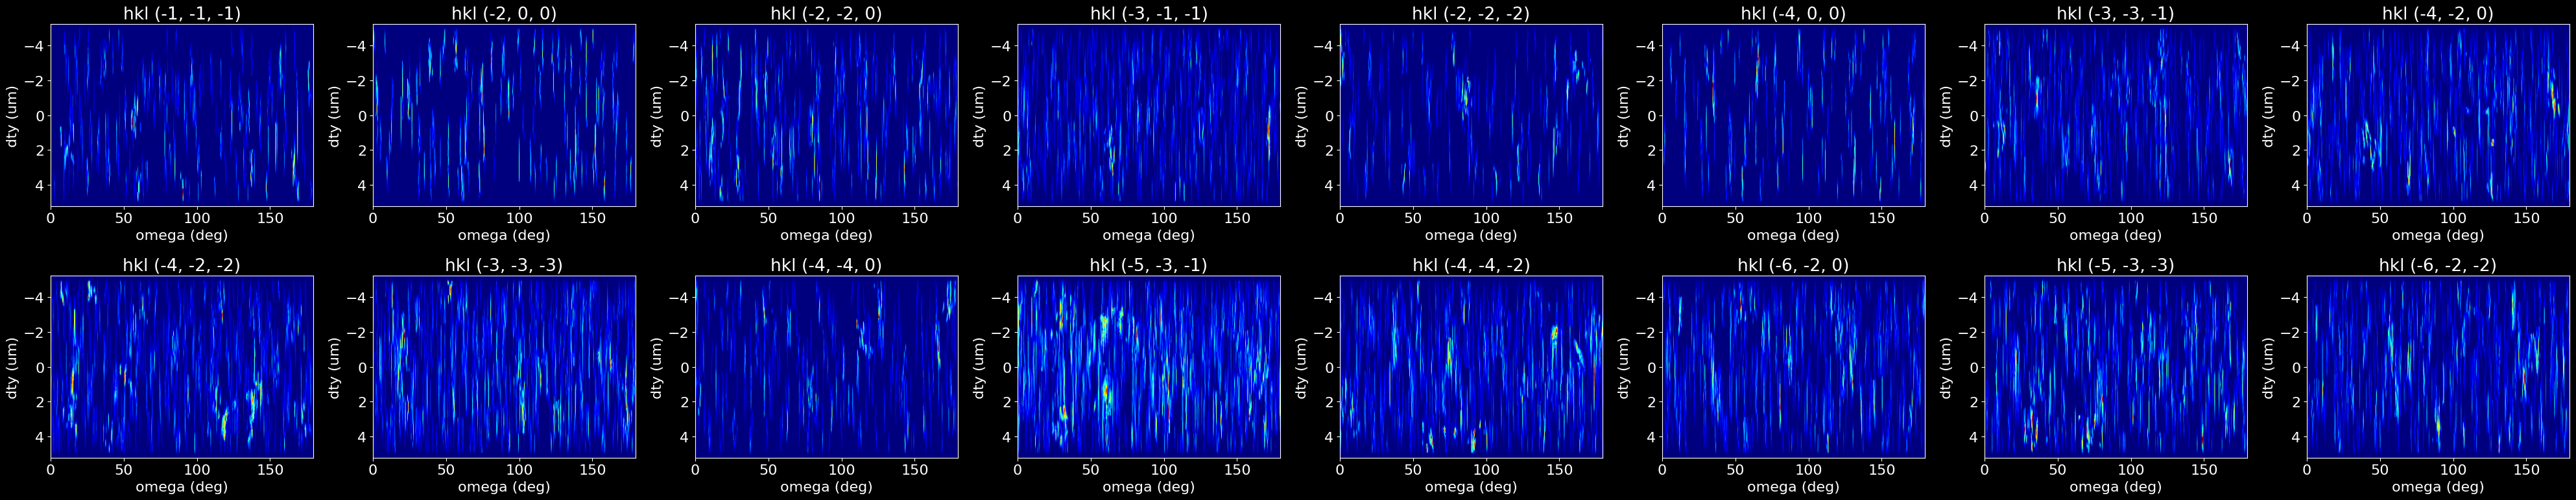

In [12]:
data = IntegratedData(OUTPUT_PATH)
assert data.polarization_corrected is True, (
    f"{data.json_path}: polarization_corrected={data.polarization_corrected} "
    "(None = not recorded, i.e. an older integration). The data must be reintegrated with the "
    "polarization correction (integration/<sample>/01_inspect_integrate.ipynb) before binning/normalisation."
)
print(data)

sinos = np.asarray(data.I).sum(axis=2)  # (translation, omega, ring)
fig, axes = plt.subplots(2, data.n_rings // 2, figsize=(5 * data.n_rings // 2, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sinos[:, :, i], aspect="auto", cmap="jet",
              extent=[data.omega_deg[0], data.omega_deg[-1], data.translations[-1], data.translations[0]])
    ax.set_title(f"hkl {tuple(data.hkl[i][0])}")
    ax.set_xlabel("omega (deg)")
    ax.set_ylabel("dty (um)")
plt.tight_layout()
plt.show()